# New Category Analysis — IT Community Discussion

This notebook analyses the impact of adding the **"IT community discussion or advice request"** category to the classifier.

**Questions we answer:**
- Are Reddit r/sysadmin posts now correctly classified into the new category?
- How many articles that previously passed the filter are now correctly rejected?
- Are there any false positives (non-Reddit articles wrongly classified as community discussion)?
- Does the new category affect classification of other sources?

## 0. Setup

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_colwidth", 120)

LABEL_WEIGHTS = {
    "cybersecurity incident or data breach":     1.0,
    "system outage or service disruption":       1.0,
    "critical software bug or vulnerability":    0.9,
    "software release or patch":                 0.5,
    "general technology news":                   0.2,
    "IT community discussion or advice request": 0.15,
}
IMPORTANCE_THRESHOLD = 0.5
NEW_CATEGORY = "IT community discussion or advice request"

conn = sqlite3.connect("news.db")
df = pd.read_sql_query("""
    SELECT id, source, title, category, importance_score, recency_score, final_score, is_filtered
    FROM articles
    ORDER BY final_score DESC
""", conn)
conn.close()

df["is_filtered"] = df["is_filtered"].astype(bool)

print(f"Total articles: {len(df)}")
print(f"  Passed filter: {df['is_filtered'].sum()}")
print(f"  Rejected:      {(~df['is_filtered']).sum()}")

Total articles: 145
  Passed filter: 82
  Rejected:      63


## 1. How many articles landed in the new category?

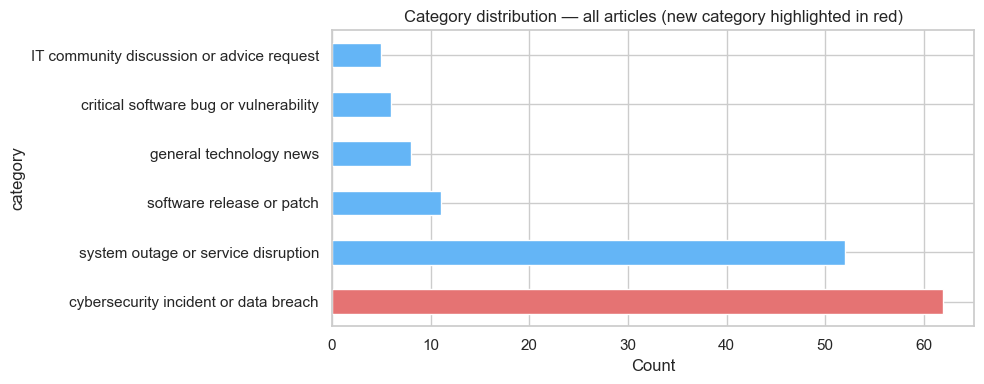

,count
category,
cybersecurity incident or data breach,62
system outage or service disruption,52
software release or patch,11
general technology news,8
critical software bug or vulnerability,6
IT community discussion or advice request,5


In [3]:
cat_counts = df["category"].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#e57373" if c == NEW_CATEGORY else "#64b5f6" for c in cat_counts.index]
cat_counts.plot(kind="barh", ax=ax, color=colors[::-1])
ax.set_title("Category distribution — all articles (new category highlighted in red)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

display(cat_counts.to_frame("count"))

## 2. Are Reddit r/sysadmin posts now correctly classified?

In [4]:
reddit = df[df["source"] == "reddit-sysadmin"].copy()

print(f"Reddit r/sysadmin articles: {len(reddit)}")
print(f"  Now correctly in new category: {(reddit['category'] == NEW_CATEGORY).sum()}")
print(f"  Still in other categories:     {(reddit['category'] != NEW_CATEGORY).sum()}")
print(f"  Passing filter (should be 0):  {reddit['is_filtered'].sum()}")

print("\nCategory breakdown for Reddit articles:")
display(reddit["category"].value_counts().to_frame("count"))

Reddit r/sysadmin articles: 25
  Now correctly in new category: 4
  Still in other categories:     21
  Passing filter (should be 0):  11

Category breakdown for Reddit articles:


,count
category,
system outage or service disruption,12
cybersecurity incident or data breach,7
IT community discussion or advice request,4
software release or patch,1


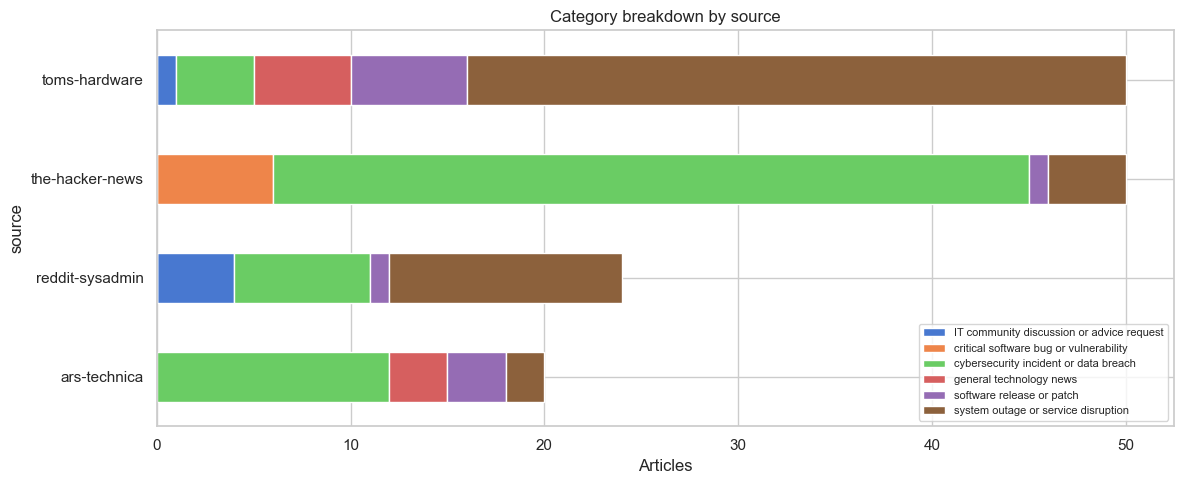

In [5]:
# Stacked bar: category breakdown per source
pivot = df.groupby(["source", "category"]).size().unstack(fill_value=0)
pivot.plot(kind="barh", stacked=True, figsize=(12, 5))
plt.title("Category breakdown by source")
plt.xlabel("Articles")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Sample articles in the new category

Check whether the titles look like genuine community discussion posts.

In [6]:
new_cat_df = df[df["category"] == NEW_CATEGORY].copy().reset_index(drop=True)

print(f"Articles classified as '{NEW_CATEGORY}': {len(new_cat_df)}")
display(new_cat_df[["title", "source", "importance_score", "is_filtered"]].round(3))

Articles classified as 'IT community discussion or advice request': 5


,title,source,importance_score,is_filtered
0,Will California age-attestation law impact device imaging and deployment?,reddit-sysadmin,0.228,False
1,"VMware, Hyper-V, Proxmox, Docker, Kubernetes, LXC... What do you use?",reddit-sysadmin,0.276,False
2,Philips 34B1U5600CH – Does USB-C + HDMI work in 50/50 PBP with hardware KVM (no software)?,reddit-sysadmin,0.216,False
3,Memory vendor under fire for imposing hefty 15% depreciation fee on returns despite skyrocketing RAM value — user ex...,toms-hardware,0.238,False
4,How do y’all handle coworkers that’s just not pulling their weight?,reddit-sysadmin,0.229,False


## 4. False positives — non-Reddit articles in the new category

These are the most concerning cases: legitimate news articles that the model wrongly classified as community discussion and therefore rejected.

In [7]:
false_positives = df[
    (df["category"] == NEW_CATEGORY) &
    (df["source"] != "reddit-sysadmin")
].copy().reset_index(drop=True)

if false_positives.empty:
    print("No false positives — only Reddit articles landed in the new category. The category is working well.")
else:
    print(f"Potential false positives: {len(false_positives)}")
    print("These non-Reddit articles were classified as community discussion and rejected:")
    display(false_positives[["title", "source", "importance_score", "is_filtered"]].round(3))

Potential false positives: 1
These non-Reddit articles were classified as community discussion and rejected:


,title,source,importance_score,is_filtered
0,Memory vendor under fire for imposing hefty 15% depreciation fee on returns despite skyrocketing RAM value — user ex...,toms-hardware,0.238,False


## 5. Reddit articles that still slipped through

Any Reddit posts that were NOT classified as the new category and still passed the filter.

In [8]:
slipped = df[
    (df["source"] == "reddit-sysadmin") &
    (df["category"] != NEW_CATEGORY) &
    (df["is_filtered"])
].copy().reset_index(drop=True)
s
if slipped.empty:
    print("No Reddit articles slipped through — all are either in the new category or rejected.")
else:
    print(f"{len(slipped)} Reddit article(s) still passed the filter with a different category:")
    display(slipped[["title", "category", "importance_score", "is_filtered"]].round(3))
    print("\nThese may be legitimate IT news shared on Reddit (e.g. a real outage report).")

11 Reddit article(s) still passed the filter with a different category:


,title,category,importance_score,is_filtered
0,CMMC L2,system outage or service disruption,0.807,True
1,"My ""I've made a massive mistake"" moment",cybersecurity incident or data breach,0.738,True
2,I've made a massive mistake,cybersecurity incident or data breach,0.815,True
3,HELP PLEASE! Had my first real email compromise incident this week. Solo IT Admin. Here's what I did — what did I miss?,cybersecurity incident or data breach,0.751,True
4,Stale trust still showing up on other DCs after deletion,cybersecurity incident or data breach,0.739,True
5,Documentation is out of date again,system outage or service disruption,0.615,True
6,HPE ProLiant Gen 11 ilo7 doesn't see SN6010Q 2P Fiber 32Gbit HBA,system outage or service disruption,0.718,True
7,1 month with Ubiquiti (so far),system outage or service disruption,0.591,True
8,Caution: Avoid The Knowledge Academy like the plague,system outage or service disruption,0.672,True
9,OpenClaw is going viral as a self-hosted ChatGPT alternative and most people setting it up have no idea what's insid...,cybersecurity incident or data breach,0.513,True



These may be legitimate IT news shared on Reddit (e.g. a real outage report).


## 6. Summary & conclusions

In [9]:
total_reddit        = len(df[df["source"] == "reddit-sysadmin"])
correctly_new_cat   = (df[df["source"] == "reddit-sysadmin"]["category"] == NEW_CATEGORY).sum()
reddit_filtered_out = (~df[df["source"] == "reddit-sysadmin"]["is_filtered"]).sum()
fp_count            = len(false_positives)
slipped_count       = len(slipped)

print("=== New category impact summary ===")
print(f"  Reddit articles total:               {total_reddit}")
print(f"  Correctly labelled as new category:  {correctly_new_cat} ({correctly_new_cat/total_reddit*100:.0f}%)")
print(f"  Now correctly filtered out:          {reddit_filtered_out}")
print(f"  False positives (non-Reddit):        {fp_count}")
print(f"  Reddit still slipping through:       {slipped_count}")

if fp_count == 0 and slipped_count == 0:
    print("\n✅ The new category is working correctly.")
elif fp_count > 0:
    print(f"\n⚠️  {fp_count} non-Reddit article(s) may have been incorrectly rejected. Review section 4.")
elif slipped_count > 0:
    print(f"\n⚠️  {slipped_count} Reddit article(s) still pass the filter. Review section 5.")

=== New category impact summary ===
  Reddit articles total:               25
  Correctly labelled as new category:  4 (16%)
  Now correctly filtered out:          14
  False positives (non-Reddit):        1
  Reddit still slipping through:       11

⚠️  1 non-Reddit article(s) may have been incorrectly rejected. Review section 4.


### What the data shows

Adding the new category helped but was **not sufficient on its own**. Looking at the slipped-through articles in section 5, the root cause is clear: posts like *"HELP PLEASE! Had my first real email compromise incident this week"* or *"I've made a massive mistake"* have titles that genuinely sound like security incidents. The model has no way to tell they are personal anecdotes or questions — from the title alone, they are indistinguishable from real news.

### Key recommendation: classify on title + description

Currently the classifier only receives the **article title**. RSS feeds also provide a **description/body** for most articles, which is already stored in the `body` column of the database.

Including the body would give the model crucial additional context:
- A real cybersecurity news article will have a body describing the attack, CVE, affected systems, etc.
- A Reddit advice post will have a body that starts with *"Hey guys, I'm dealing with..."* or *"Any recommendations for..."*

This distinction is almost impossible to make from the title alone, but becomes obvious with even a few sentences of body text. Passing `title + body` to the zero-shot pipeline would likely resolve the majority of the remaining misclassifications without requiring any changes to the label set or weights.